# Task1 - Environment Setup & Data Loading

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



#Load csv files into pandas dataframes
drivers = pd.read_csv("data/drivers.csv")
races = pd.read_csv("data/races.csv")
results = pd.read_csv("data/results.csv")
constructors = pd.read_csv("data/constructors.csv")
circuits = pd.read_csv("data/circuits.csv")

dataframes = {
    "drivers": drivers,
    "races": races,
    "results": results,
    "constructors": constructors,
    "circuits": circuits
}


# Display the shape and data types of each dataframe
for name, df in dataframes.items():
    print("=" * 50)
    print(f"{name.upper()}")
    print(f"Shape: {df.shape}\n")
    print("Data Types:")
    print(df.dtypes)
    print("\n")


# Display the shape and data types of each dataframe
for name, df in dataframes.items():
    print("=" * 50)
    print(f"{name.upper()}")
    print(f"Shape: {df.shape}\n")
    print("Data Types:")
    print(df.dtypes)
    print("\n")

DRIVERS
Shape: (861, 9)

Data Types:
driverId       int64
driverRef        str
number           str
code             str
forename         str
surname          str
dob              str
nationality      str
url              str
dtype: object


RACES
Shape: (1125, 18)

Data Types:
raceId         int64
year           int64
round          int64
circuitId      int64
name             str
date             str
time             str
url              str
fp1_date         str
fp1_time         str
fp2_date         str
fp2_time         str
fp3_date         str
fp3_time         str
quali_date       str
quali_time       str
sprint_date      str
sprint_time      str
dtype: object


RESULTS
Shape: (26759, 18)

Data Types:
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number                 str
grid                 int64
position               str
positionText           str
positionOrder        int64
points             float64
laps             

# Task2 - Data Cleaning

In [248]:
# 1. results.csv 
results_cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']

print("=== results.csv ===")
print(f"Total rows: {len(results)}\n")

for col in results_cols:
    n_missing = (results[col].astype(str) == '\\N').sum()
    pct = n_missing / len(results) * 100
    print(f"{col}: {n_missing} missing ({pct:.2f}%)")

before = pd.DataFrame({
    "Before": results[results_cols].isna().sum()
})
results.head(15)

# 2. drivers.csv
drivers_cols = ['dob', 'nationality']

print("\n=== drivers.csv ===")
print(f"Total rows: {len(drivers)}\n")

for col in drivers_cols:
    n_missing = (drivers[col].astype(str) == '\\N').sum()
    pct = n_missing / len(drivers) * 100
    print(f"{col}: {n_missing} missing ({pct:.2f}%)")


=== results.csv ===
Total rows: 26759

milliseconds: 19079 missing (71.30%)
fastestLapTime: 18507 missing (69.16%)
fastestLapSpeed: 18507 missing (69.16%)

=== drivers.csv ===
Total rows: 861

dob: 0 missing (0.00%)
nationality: 0 missing (0.00%)


### additional note - why results.csv has so many missing values?

#### 1. a lack of record from the past

In [249]:
# Merge to bring in the 'year' column
results = results.merge(races[['raceId', 'year']], on='raceId', how='left')

# Split into pre-2000s and post-2000s (2000 onward)
pre_2000 = results[results['year'] < 2000]
post_2000 = results[results['year'] >= 2000]

def missing_pct(df, col):
    n_missing = (df[col].astype(str) == '\\N').sum()
    return n_missing / len(df) * 100

cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']

print(f"Pre-2000 rows: {len(pre_2000)}")
print(f"Post-2000 rows: {len(post_2000)}\n")

print(f"{'Column':<18}{'Pre-2000 missing %':<22}{'Post-2000 missing %'}")
for col in cols:
    pre_pct = missing_pct(pre_2000, col)
    post_pct = missing_pct(post_2000, col)
    print(f"{col:<18}{pre_pct:<22.2f}{post_pct:.2f}")


Pre-2000 rows: 16680
Post-2000 rows: 10079

Column            Pre-2000 missing %    Post-2000 missing %
milliseconds      82.15                 53.34
fastestLapTime    100.00                18.13
fastestLapSpeed   100.00                18.13


#### 2. a result of DNF

In [250]:
cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']

for col in cols:
    missing_mask = results[col].astype(str) == '\\N'
    n_missing = missing_mask.sum()
    
    # Among the missing rows, how many are DNF (positionText == 'R')?
    n_dnf_in_missing = (results.loc[missing_mask, 'positionText'] == 'R').sum()
    dnf_ratio = n_dnf_in_missing / n_missing * 100 if n_missing > 0 else 0
    
    print(f"=== {col} ===")
    print(f"Total missing: {n_missing}")
    print(f"Missing rows that are DNF (positionText == 'R'): {n_dnf_in_missing}")
    print(f"DNF ratio among missing: {dnf_ratio:.2f}%\n")

=== milliseconds ===
Total missing: 19079
Missing rows that are DNF (positionText == 'R'): 8897
DNF ratio among missing: 46.63%

=== fastestLapTime ===
Total missing: 18507
Missing rows that are DNF (positionText == 'R'): 7704
DNF ratio among missing: 41.63%

=== fastestLapSpeed ===
Total missing: 18507
Missing rows that are DNF (positionText == 'R'): 7704
DNF ratio among missing: 41.63%



As you can see, the missing values in results.csv are highly influenced by lack of record before 2000. And high ratio of DNF caused a lot of missing values as well.


# Task3 - Merge Master Dataset

In [251]:
# Build driver full name
drivers['driverName'] = drivers['forename'] + ' ' + drivers['surname']

race_cols = ['raceId', 'round']
merged = results.merge(races[race_cols], on='raceId', how='left')

# Merge in driver names
merged = merged.merge(drivers[['driverId', 'driverName']], on='driverId', how='left')

# Merge in constructor names
merged = merged.merge(
    constructors[['constructorId', 'name']].rename(columns={'name': 'constructorName'}),
    on='constructorId', how='left'
)

# Select the required columns
final_cols = [
    'raceId', 'year', 'round', 'driverName', 'constructorName',
    'grid', 'position', 'points', 'statusId'
]

merged_f1 = merged[final_cols]

print(merged_f1.shape)
print(merged_f1.head())

# Export to CSV
merged_f1.to_csv('jaeeun/output/merged_f1.csv', index=False)

(26759, 9)
   raceId  year  round         driverName constructorName  grid position  \
0      18  2008      1     Lewis Hamilton         McLaren     1        1   
1      18  2008      1      Nick Heidfeld      BMW Sauber     5        2   
2      18  2008      1       Nico Rosberg        Williams     7        3   
3      18  2008      1    Fernando Alonso         Renault    11        4   
4      18  2008      1  Heikki Kovalainen         McLaren     3        5   

   points  statusId  
0    10.0         1  
1     8.0         1  
2     6.0         1  
3     5.0         1  
4     4.0         1  


# Task4 - Top Drivers by Career Points

In [252]:
# If results already has year, avoid merging year again
if 'year' in results.columns:
    result_races = results.copy()
else:
    result_races = results.merge(
        races[['raceId', 'year']],
        on='raceId',
        how='left'
    )

result_races = result_races[
    (result_races["year"] >= 1995) &
    (result_races["year"] <= 2020)
]

career_points = result_races.groupby('driverId', as_index=False).agg(
    Total_Points=('points', 'sum')
)

career_points = career_points.merge(
    drivers[["driverId", "forename", "surname"]],
    on="driverId",
    how="left"
)

career_points["driver"] = (
    career_points["forename"] + " " + career_points["surname"]
)

top10 = (
    career_points[["driver", "Total_Points"]]
    .sort_values("Total_Points", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10

,driver,Total_Points
0,Lewis Hamilton,3778.0
1,Sebastian Vettel,3018.0
2,Fernando Alonso,1899.0
3,Kimi Räikkönen,1863.0
4,Nico Rosberg,1594.5
5,Valtteri Bottas,1512.0
6,Michael Schumacher,1365.0
7,Jenson Button,1235.0
8,Felipe Massa,1167.0
9,Max Verstappen,1162.0


/var/folders/dr/v66_x2k55hbc5gf4xyt07q4h0000gn/T/ipykernel_28550/1625003183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


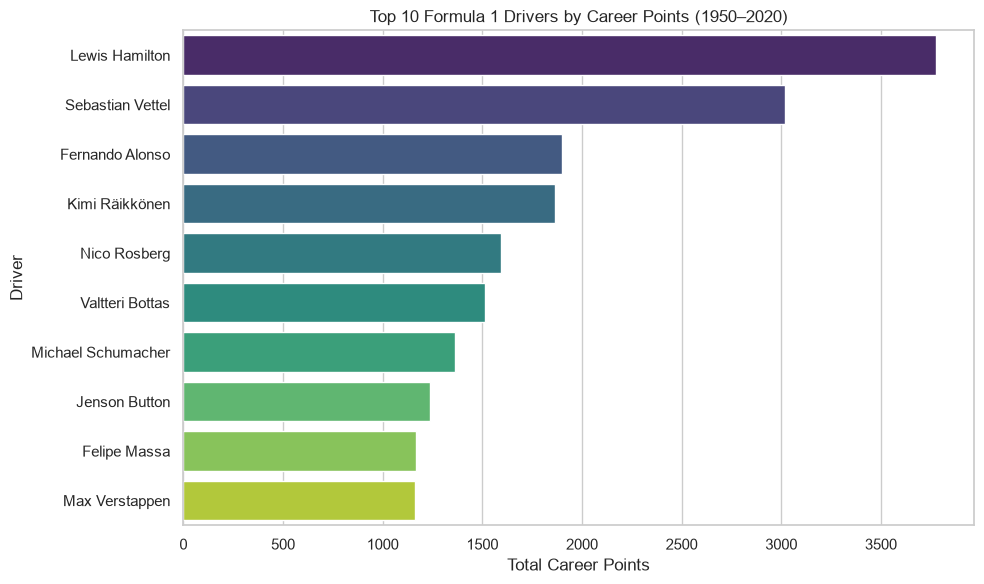

In [253]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="Total_Points",
    y="driver",
    palette="viridis"
)

plt.title("Top 10 Formula 1 Drivers by Career Points (1950–2020)")
plt.xlabel("Total Career Points")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

# Task5 - Top Constructors by Decade

In [254]:
results_with_position = results.assign(
    position=pd.to_numeric(results["position"], errors="coerce")
)

wins = results_with_position[results_with_position["position"] == 1].copy()

if "year" not in wins.columns:
    wins = wins.merge(races[["raceId", "year"]], on="raceId", how="left")

wins = wins.merge(
    constructors[["constructorId", "name"]],
    on="constructorId",
    how="left"
)

wins["decade"] = (wins["year"] // 10 * 10).astype(int).astype(str) + "s"

wins_by_decade = (
    wins
    .groupby(["decade", "name"])
    .size()
    .reset_index(name="wins")
    .sort_values(["decade", "wins"], ascending=[True, False])
)

wins_pivot = (
    wins_by_decade
    .pivot(index="name", columns="decade", values="wins")
    .fillna(0)
    .astype(int)
)

wins_pivot

decade,1950s,1960s,1970s,1980s,1990s,2000s,2010s,2020s
name,,,,,,,,
Alfa Romeo,11,0,0,0,0,0,0,0
AlphaTauri,0,0,0,0,0,0,0,1
Alpine F1 Team,0,0,0,0,0,0,0,1
BMW Sauber,0,0,0,0,0,1,0,0
BRM,1,12,4,0,0,0,0,0
Benetton,0,0,0,2,25,0,0,0
Brabham,0,0,8,15,0,0,0,0
Brabham-Climax,0,2,0,0,0,0,0,0
Brabham-Ford,0,2,0,0,0,0,0,0


# Task6 - NumPy Statistics on Finishing Position

In [255]:
results["positionOrder"] = pd.to_numeric(results["positionOrder"], errors='coerce')

driver_names = ["Lewis Hamilton", "Michael Schumacher"]

selected = drivers.copy()
selected["driver"] = selected["forename"] + " " + selected["surname"]

selected = selected[selected["driver"].isin(driver_names)]
selected
hamilton_id = selected[selected["driver"]=="Lewis Hamilton"]["driverId"].iloc[0]
schumacher_id = selected[selected["driver"]=="Michael Schumacher"]["driverId"].iloc[0]

hamilton_pos = results.loc[
    results["driverId"] == hamilton_id,
    "positionOrder"
].to_numpy()

schumacher_pos = results.loc[
    results["driverId"] == schumacher_id,
    "positionOrder"
].to_numpy()
comparison = pd.DataFrame({
    "Driver": driver_names,
    "Mean Finish": [
        np.mean(hamilton_pos),
        np.mean(schumacher_pos)
    ],
    "Median Finish": [
        np.median(hamilton_pos),
        np.median(schumacher_pos)
    ],
    "Std Dev": [
        np.std(hamilton_pos),
        np.std(schumacher_pos)
    ]
})

comparison

,Driver,Mean Finish,Median Finish,Std Dev
0,Lewis Hamilton,5.019663,3.0,5.543207
1,Michael Schumacher,6.879870,3.0,7.061087


# Task7 - Chart 1 - Races per Season

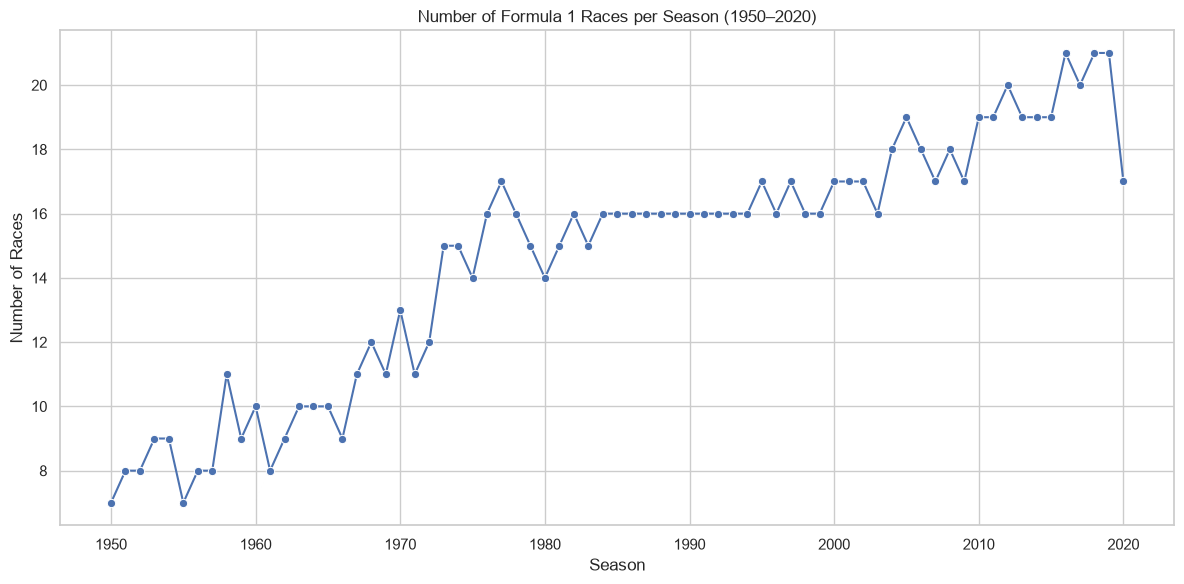

In [256]:
result_races = races[(races["year"] >= 1950) 
                            & (races["year"] <= 2020)]

result_races
num_of_races = (
    result_races
    .groupby("year")
    .size()
    .reset_index(name="num_of_races")    
)

num_of_races
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

#graph drawing
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=num_of_races,
    x="year",
    y="num_of_races",
    marker="o"
)

plt.title("Number of Formula 1 Races per Season (1950–2020)")
plt.xlabel("Season")
plt.ylabel("Number of Races")

plt.tight_layout()

# saving as png
plt.savefig("jaeeun/output/chart1_races_per_season.png", dpi=300)

plt.show()

# Task8 - Chart 2 - Top 10 Drivers by Wins

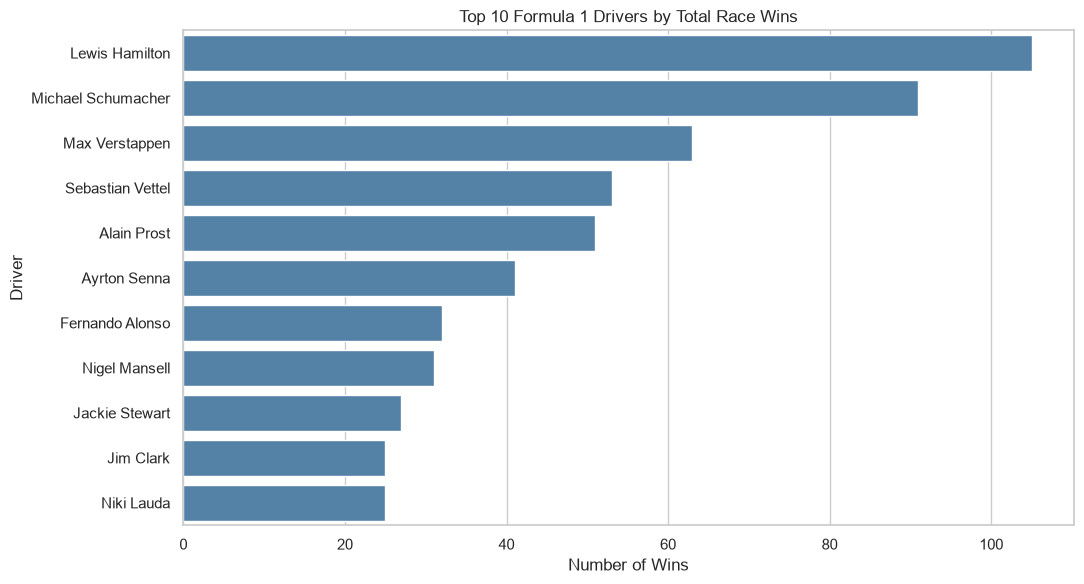

In [257]:
results_with_position = results.assign(
    position=pd.to_numeric(results["position"], errors="coerce")
)

wins_only = results_with_position[results_with_position["position"] == 1]

wins_by_driver = (
    wins_only
    .groupby("driverId")
    .size()
    .reset_index(name="wins")
    .merge(drivers[["driverId", "forename", "surname"]], on="driverId", how="left")
)

wins_by_driver["driver"] = (
    wins_by_driver["forename"] + " " + wins_by_driver["surname"]
)

top10_wins = (
    wins_by_driver[["driver", "wins"]]
    .sort_values("wins", ascending=False)
    .head(11)
    .reset_index(drop=True)
)


plt.figure(figsize=(11, 6))

sns.barplot(
    data=top10_wins,
    x="wins",
    y="driver",
    color="steelblue",   # choose any color you like
)

plt.title("Top 10 Formula 1 Drivers by Total Race Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Driver")
plt.tight_layout()
plt.savefig("jaeeun/output/chart2_top10_wins.png", dpi=300)
plt.show()

# Task9 - Chart 3 - Grid vs Finish Position

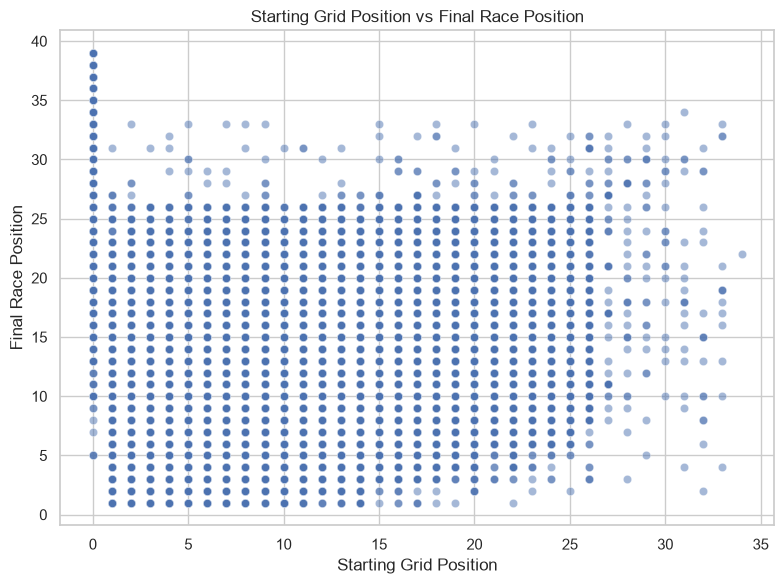

In [258]:
#copying the relevant columns for plotting
plot_data = results[["grid", "positionOrder"]].copy()

plot_data["grid"] = pd.to_numeric(plot_data["grid"], errors="coerce")
plot_data["positionOrder"] = pd.to_numeric(
    plot_data["positionOrder"],
    errors="coerce"
)

plot_data = plot_data.dropna()

# Calculate the correlation coefficient between starting grid
correlation = np.corrcoef(
    plot_data["grid"],
    plot_data["positionOrder"]
)[0, 1]

# Display the correlation coefficient
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_data,
    x="grid",
    y="positionOrder",
    alpha=0.5
)

plt.title("Starting Grid Position vs Final Race Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Final Race Position")

plt.tight_layout()

plt.savefig("jaeeun/output/chart3_grid_vs_finish.png", dpi=300)

plt.show()



### Write a short summary/report describing 3 key insights discovered from the analysis above.

### **Task 2 – Missing Values**

A detailed investigation of the missing values in `results.csv` revealed two main causes. First, many missing values are associated with **DNF (Did Not Finish)** records, where race completion statistics are unavailable. Second, before the 2000s, race timing systems were less developed, resulting in almost all values for `milliseconds`, `fastestLapTime`, and `fastestLapSpeed` being unrecorded and therefore stored as missing values. Consequently, analyses involving these variables should consider separating data from the pre-2000 and post-2000 periods to avoid biased interpretations.

---

### **Task 7 – Number of Races by Season**

The number of races per season generally increased from 1995 to 2019, reflecting the expansion of the Formula 1 calendar. However, the 2020 season shows an exceptional decline, with the number of races falling to a level similar to that of 2007 and 2009. This decrease was most likely caused by the global COVID-19 pandemic, which led to race cancellations and schedule changes.

---

### **Task 9 – Starting Grid Position**

Starting grid position is positively associated with final race position, indicating that drivers who start closer to the front are more likely to finish in higher positions. However, because the starting grid is determined by qualifying performance rather than assigned randomly, this relationship should be interpreted as an association rather than evidence of a causal effect. Driver skill, car performance, and team competitiveness are likely to influence both qualifying and race results.

# Task11 - Driver Consistency Score

1. Aggregates points, DNF rate, and race count per driver-season
2. Computes each driver's teammate-relative position difference (mean and std) within the same race/constructor
3. Calculates points CV to normalize volatility by scoring level, and min-max normalizes all metrics within each season to avoid cross-era distortion
4. Combines them into a weighted consistency_score 
5. Merges driver names and prints season-by-season top-10 rankings.


Consistency Score
= 0.30 × (Normalized Points)
+ 0.20 × (1 − Normalized Std)
+ 0.15 x (1 - Normalized DNF)
+ 0.20 × Normalized Teammate Relative Score
+ 0.15 * (1 - Normalized Teammate Relative Std)

In [259]:
if 'year' not in results.columns:
    results = results.merge(races[['raceId', 'year']], on='raceId', how='left')

# driverId + year 
consistency = results.groupby(['driverId', 'year']).agg(
    avg_points_per_race=('points', 'mean'),
    std_points=('points', 'std'),
    race_count=('raceId', 'count'),
    DNF_Rate=('statusId', lambda x: (x != 1).sum() / len(x) * 100)
).reset_index()

consistency = consistency[consistency['race_count'] >= 5]  # season unit

# teammate relative performance 
team_size = results.groupby(['raceId', 'constructorId'])['driverId'].transform('count')

results['teammate_diff'] = results.groupby(['raceId', 'constructorId'])['positionOrder']\
    .transform(lambda x: x.mean() - x)
results.loc[team_size < 2, 'teammate_diff'] = np.nan

teammate_stats = results.groupby(['driverId', 'year']).agg(
    teammate_diff_mean=('teammate_diff', 'mean'),
    teammate_diff_std=('teammate_diff', 'std')
).reset_index()

consistency = consistency.merge(teammate_stats, on=['driverId', 'year'], how='left')
consistency = consistency.dropna(subset=['teammate_diff_mean', 'teammate_diff_std'])

# CV calculation
consistency['cv_points'] = consistency['std_points'] / (consistency['avg_points_per_race'] + 0.1)

# normalizing across a season
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

consistency['norm_points']       = consistency.groupby('year')['avg_points_per_race'].transform(normalize)
consistency['norm_cv']           = consistency.groupby('year')['cv_points'].transform(normalize)
consistency['norm_dnf']          = consistency.groupby('year')['DNF_Rate'].transform(normalize)
consistency['norm_teammate']     = consistency.groupby('year')['teammate_diff_mean'].transform(normalize)
consistency['norm_teammate_std'] = consistency.groupby('year')['teammate_diff_std'].transform(normalize)

# Consistency Score 
consistency['consistency_score'] = (
    0.30 * consistency['norm_points'] +
    0.20 * (1 - consistency['norm_cv']) +
    0.15 * (1 - consistency['norm_dnf']) +
    0.20 * consistency['norm_teammate'] +
    0.15 * (1 - consistency['norm_teammate_std'])
)

# driver name merge
consistency = consistency.merge(
    drivers[['driverId', 'forename', 'surname']],
    on='driverId',
    how='left'
)
consistency['driver_name'] = consistency['forename'] + ' ' + consistency['surname']

# season-wise ranking
consistency_ranked_2015 = consistency[consistency['year'] == 2015].sort_values(
    'consistency_score', ascending=False
)[['driverId', 'driver_name', 'year', 'consistency_score']].reset_index(drop=True)


years = sorted(consistency['year'].unique())

for y in years[::-1]:
    print(f"\n===== {y}년 =====")
    display(
        consistency[consistency['year'] == y]
        .sort_values('consistency_score', ascending=False)
        [['driverId', 'driver_name', 'consistency_score']]
        .reset_index(drop=True)
        .head(10)  
    )


===== 2024년 =====


,driverId,driver_name,consistency_score
0,830,Max Verstappen,0.818791
1,844,Charles Leclerc,0.738017
2,846,Lando Norris,0.726203
3,832,Carlos Sainz,0.642799
4,857,Oscar Piastri,0.639063
5,847,George Russell,0.560260
6,1,Lewis Hamilton,0.536705
7,4,Fernando Alonso,0.466860
8,822,Valtteri Bottas,0.420397
9,858,Logan Sargeant,0.408271



===== 2023년 =====


,driverId,driver_name,consistency_score
0,830,Max Verstappen,0.942133
1,4,Fernando Alonso,0.687806
2,846,Lando Norris,0.622959
3,1,Lewis Hamilton,0.601954
4,815,Sergio Pérez,0.532981
5,848,Alexander Albon,0.506402
6,842,Pierre Gasly,0.502456
7,832,Carlos Sainz,0.494132
8,859,Liam Lawson,0.464156
9,847,George Russell,0.459340



===== 2022년 =====


...

,driverId,driver_name,consistency_score
0,647,Alberto Ascari,0.920518
1,642,Nino Farina,0.509527
2,641,Piero Taruffi,0.447702
3,475,Stirling Moss,0.410179
4,651,Lance Macklin,0.371827
5,581,Peter Collins,0.297193
6,660,Johnny Claes,0.286559
7,578,Mike Hawthorn,0.276209
8,723,Rudi Fischer,0.271986
9,626,Robert Manzon,0.259163



===== 1951년 =====


,driverId,driver_name,consistency_score
0,498,José Froilán González,0.832960
1,579,Juan Fangio,0.765837
2,647,Alberto Ascari,0.557709
3,633,Luigi Villoresi,0.520223
4,642,Nino Farina,0.475112
5,660,Johnny Claes,0.429521
6,641,Piero Taruffi,0.377941
7,627,Louis Rosier,0.348098
8,589,Louis Chiron,0.315635
9,741,Philippe Étancelin,0.291851



===== 1950년 =====


,driverId,driver_name,consistency_score
0,786,Luigi Fagioli,0.816215
1,642,Nino Farina,0.696145
2,627,Louis Rosier,0.501643
3,579,Juan Fangio,0.432912
4,660,Johnny Claes,0.384510
5,647,Alberto Ascari,0.364301
6,741,Philippe Étancelin,0.313510
7,793,Raymond Sommer,0.126969
8,589,Louis Chiron,0.094859
